# DSCI 552 - Homework 2

**Name:** Zexin Xiong  
**GitHub Username:** zexinxiong  
**USC ID:** 6510910225

This notebook studies the Combined Cycle Power Plant data set. The response is hourly net electrical energy output, `PE`, and the predictors are `AT`, `V`, `AP`, and `RH`.

## 1(a). Data

The data were downloaded from the UCI Combined Cycle Power Plant data set. The homework asks us to work with Sheet 1; the Excel workbook under `../data/CCPP/` loads Sheet 1 by default.

In [1]:
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = "../data/CCPP/Folds5x2_pp.xlsx"
df = pd.read_excel(DATA_PATH, sheet_name=0)
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b). Exploring the Data

In [2]:
n_rows, n_cols = df.shape
print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")
print(df.dtypes)

Rows: 9568
Columns: 5
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


There are 9,568 rows and 5 columns. Each row is one hourly observation from the power plant. The columns are:

- `AT`: ambient temperature
- `V`: exhaust vacuum
- `AP`: ambient pressure
- `RH`: relative humidity
- `PE`: net hourly electrical energy output, the response variable

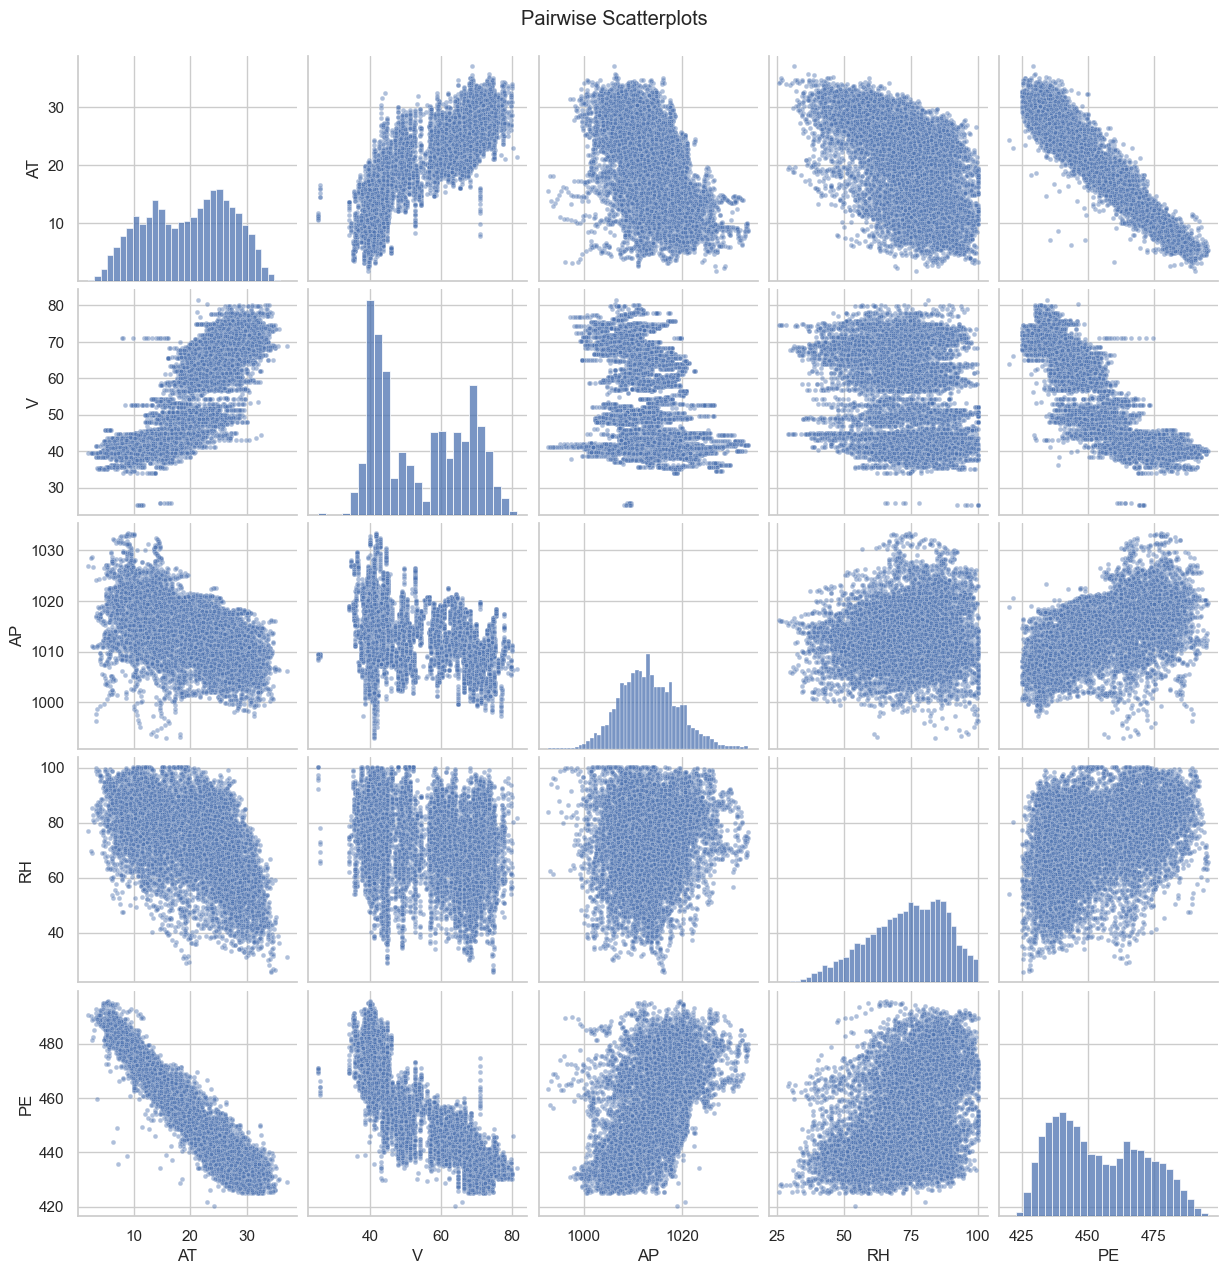

In [3]:
pairplot = sns.pairplot(df, diag_kind="hist", plot_kws={"s": 12, "alpha": 0.45})
pairplot.fig.suptitle("Pairwise Scatterplots", y=1.02)
plt.show()

The pairwise plots show a strong negative association between `AT` and `PE`, and also a clear negative association between `V` and `PE`. `AP` has a weaker positive relationship with `PE`, while `RH` appears weaker and somewhat nonlinear. The predictors are not fully independent: for example, `AT` and `V` have a visible positive relationship, so multiple regression coefficients may differ from simple regression coefficients.

In [4]:
summary = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "range": df.max() - df.min(),
    "first_quartile": df.quantile(0.25),
    "third_quartile": df.quantile(0.75),
})
summary["IQR"] = summary["third_quartile"] - summary["first_quartile"]
summary.round(3)

,mean,median,range,first_quartile,third_quartile,IQR
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


## 1(c). Simple Linear Regression

In [5]:
predictors = ["AT", "V", "AP", "RH"]
response = "PE"

simple_results = []
simple_models = {}

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df[response]
    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model
    simple_results.append({
        "predictor": predictor,
        "intercept": model.params["const"],
        "coefficient": model.params[predictor],
        "p_value": model.pvalues[predictor],
        "r_squared": model.rsquared,
    })

simple_table = pd.DataFrame(simple_results)
simple_table

,predictor,intercept,coefficient,p_value,r_squared
0,AT,497.034120,-2.171320,0.0,0.898948
1,V,517.801526,-1.168135,0.0,0.756518
2,AP,-1055.260989,1.489872,0.0,0.268769
3,RH,420.961766,0.455650,0.0,0.151939


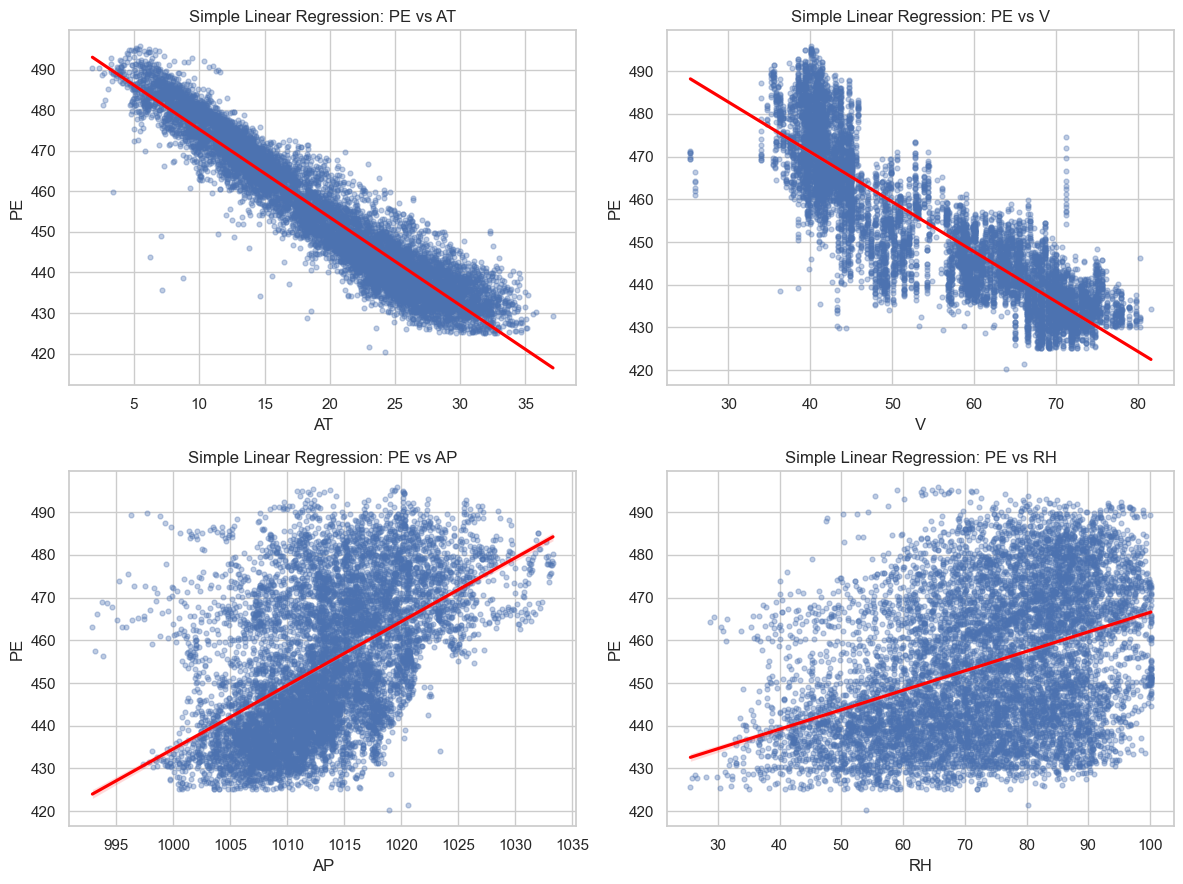

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, predictor in zip(axes, predictors):
    sns.regplot(data=df, x=predictor, y=response, ax=ax, scatter_kws={"s": 12, "alpha": 0.35}, line_kws={"color": "red"})
    ax.set_title(f"Simple Linear Regression: PE vs {predictor}")

plt.tight_layout()
plt.show()

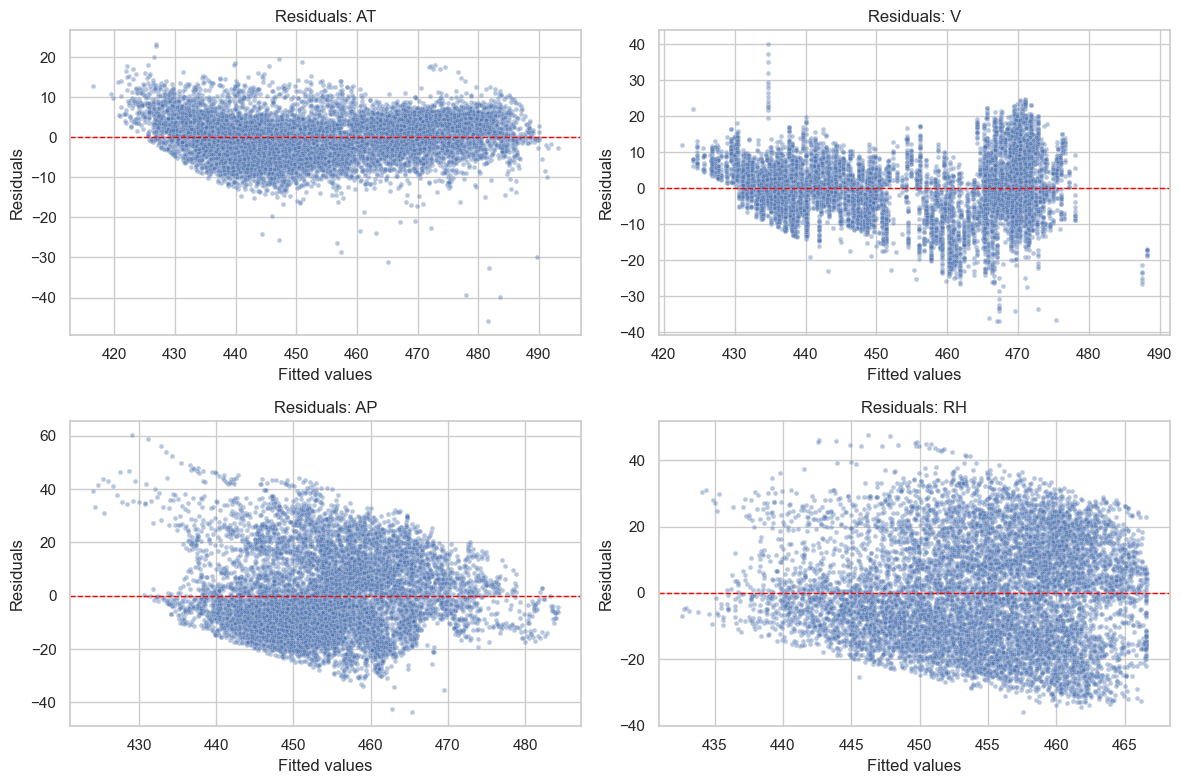

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, predictor in zip(axes, predictors):
    model = simple_models[predictor]
    fitted = model.fittedvalues
    resid = model.resid
    sns.scatterplot(x=fitted, y=resid, ax=ax, s=12, alpha=0.4)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Residuals: {predictor}")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

All four simple regression models have very small p-values, so each predictor has a statistically significant association with `PE` when considered by itself. `AT` has the strongest simple relationship by far, followed by `V`. The residual plots show some curvature and nonconstant spread, especially for `AT`, `V`, and `RH`, which suggests that nonlinear terms may help. There are some points with larger residuals, but they do not appear to be obvious data-entry errors, so I keep all observations.

## 1(d). Multiple Linear Regression

In [8]:
X_multi = sm.add_constant(df[predictors])
y = df[response]
multi_model = sm.OLS(y, X_multi).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:34:57   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In the multiple regression model, all four predictors have p-values below 0.05. Therefore, we reject the null hypothesis \(H_0: \beta_j = 0\) for `AT`, `V`, `AP`, and `RH`.

## 1(e). Comparing Simple and Multiple Regression Coefficients

,predictor,simple_coefficient,multiple_coefficient
0,AT,-2.171320,-1.977513
1,V,-1.168135,-0.233916
2,AP,1.489872,0.062083
3,RH,0.455650,-0.158054


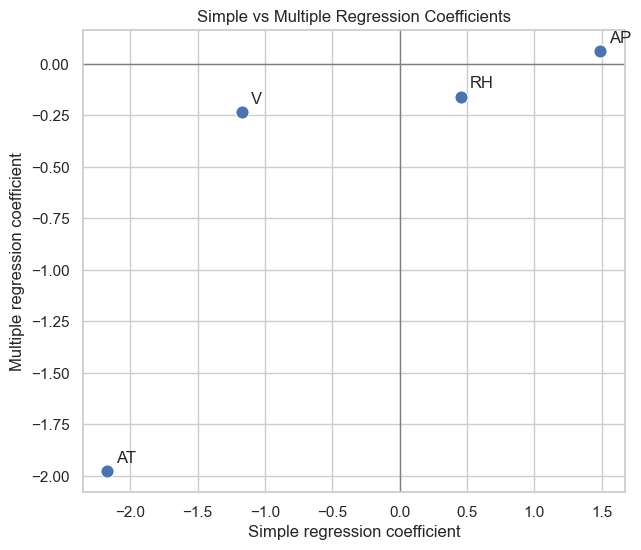

In [9]:
coef_compare = pd.DataFrame({
    "predictor": predictors,
    "simple_coefficient": [simple_models[p].params[p] for p in predictors],
    "multiple_coefficient": [multi_model.params[p] for p in predictors],
})
display(coef_compare)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=coef_compare, x="simple_coefficient", y="multiple_coefficient", s=90)
for _, row in coef_compare.iterrows():
    plt.annotate(row["predictor"], (row["simple_coefficient"], row["multiple_coefficient"]), xytext=(6, 6), textcoords="offset points")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.xlabel("Simple regression coefficient")
plt.ylabel("Multiple regression coefficient")
plt.title("Simple vs Multiple Regression Coefficients")
plt.show()

The signs mostly agree between simple and multiple regression, but the magnitudes change. This happens because the predictors are correlated with one another. The simple coefficient measures the marginal association with `PE`, while the multiple coefficient measures the association after adjusting for the other predictors.

## 1(f). Polynomial Regression for Nonlinear Association

In [10]:
poly_results = []
for predictor in predictors:
    X_poly = pd.DataFrame({
        predictor: df[predictor],
        f"{predictor}^2": df[predictor] ** 2,
        f"{predictor}^3": df[predictor] ** 3,
    })
    X_poly = sm.add_constant(X_poly)
    model = sm.OLS(y, X_poly).fit()
    for term in X_poly.columns:
        if term != "const":
            poly_results.append({
                "predictor": predictor,
                "term": term,
                "coefficient": model.params[term],
                "p_value": model.pvalues[term],
            })

poly_table = pd.DataFrame(poly_results)
poly_table

,predictor,term,coefficient,p_value
0,AT,AT,-0.610346,7.898147e-07
1,AT,AT^2,-0.125138,8.833045e-73
2,AT,AT^3,0.002675,3.652185e-110
3,V,V,-2.144377,2.526589e-05
4,V,V^2,-0.002712,7.684969e-01
5,V,V^3,0.000134,1.373489e-02
6,AP,AP,25.255593,4.502735e-17
7,AP,AP^2,-0.049952,3.666705e-17
8,AP,AP^3,0.000025,8.264146e-18
9,RH,RH,-1.729211,3.772510e-04


In [11]:
for predictor in predictors:
    print(f"\nPolynomial model for {predictor}")
    terms = poly_table[poly_table["predictor"] == predictor][["term", "coefficient", "p_value"]]
    display(terms)


Polynomial model for AT


,term,coefficient,p_value
0,AT,-0.610346,7.898147e-07
1,AT^2,-0.125138,8.833045e-73
2,AT^3,0.002675,3.652185e-110



Polynomial model for V


,term,coefficient,p_value
3,V,-2.144377,0.000025
4,V^2,-0.002712,0.768497
5,V^3,0.000134,0.013735



Polynomial model for AP


,term,coefficient,p_value
6,AP,25.255593,4.502735e-17
7,AP^2,-0.049952,3.666705e-17
8,AP^3,0.000025,8.264146e-18



Polynomial model for RH


,term,coefficient,p_value
9,RH,-1.729211,0.000377
10,RH^2,0.032145,0.000009
11,RH^3,-0.000152,0.000014


The polynomial regressions show evidence of nonlinear association for the predictors whose quadratic or cubic terms are statistically significant. In this data set, the polynomial terms for `AT`, `V`, `AP`, and `RH` are significant at the 0.05 level, so there is evidence of nonlinear association between each predictor and `PE`.

## 1(g). Pairwise Interaction Terms

In [12]:
X_inter = df[predictors].copy()
interaction_terms = []
for a, b in itertools.combinations(predictors, 2):
    term = f"{a}:{b}"
    X_inter[term] = df[a] * df[b]
    interaction_terms.append(term)

inter_model = sm.OLS(y, sm.add_constant(X_inter)).fit()
inter_table = pd.DataFrame({
    "term": inter_model.params.index,
    "coefficient": inter_model.params.values,
    "p_value": inter_model.pvalues.values,
})
inter_table[inter_table["term"].isin(interaction_terms)].sort_values("p_value")

,term,coefficient,p_value
5,AT:V,0.020971,3.333358e-117
7,AT:RH,-0.005230,1.216944e-10
8,V:AP,0.006812,2.877026e-07
10,AP:RH,-0.001612,3.360557e-02
9,V:RH,0.000839,8.619366e-02
6,AT:AP,0.001759,4.520509e-01


The interaction table lists the pairwise interaction terms. Terms with p-values below 0.05 are statistically significant, giving evidence that the effect of one predictor on `PE` depends on the value of another predictor.

## 1(h). Train/Test MSE for Linear and Improved Models

In [13]:
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42)

def fit_ols(train, test, cols):
    X_train = sm.add_constant(train[cols], has_constant="add")
    X_test = sm.add_constant(test[cols], has_constant="add")
    model = sm.OLS(train[response], X_train).fit()
    train_mse = mean_squared_error(train[response], model.predict(X_train))
    test_mse = mean_squared_error(test[response], model.predict(X_test))
    return model, train_mse, test_mse

base_model, base_train_mse, base_test_mse = fit_ols(train_df, test_df, predictors)

def add_engineered_terms(data):
    out = data[predictors].copy()
    for col in predictors:
        out[f"{col}^2"] = data[col] ** 2
    for a, b in itertools.combinations(predictors, 2):
        out[f"{a}:{b}"] = data[a] * data[b]
    return out

X_train_full = add_engineered_terms(train_df)
X_test_full = add_engineered_terms(test_df)

def dependencies(term):
    if "^2" in term:
        return [term.split("^")[0]]
    if ":" in term:
        return term.split(":")
    return []

selected = list(X_train_full.columns)

while True:
    X_sel = sm.add_constant(X_train_full[selected], has_constant="add")
    model = sm.OLS(train_df[response], X_sel).fit()
    pvals = model.pvalues.drop("const")

    removable = []
    for term, p_value in pvals.items():
        if term in predictors:
            used_by_selected_higher_order = any(term in dependencies(other) for other in selected if other != term)
            if used_by_selected_higher_order:
                continue
        removable.append((term, p_value))

    if not removable:
        break

    worst_term, worst_p = max(removable, key=lambda item: item[1])
    if worst_p <= 0.05:
        break
    selected.remove(worst_term)

reduced_model, improved_train_mse, improved_test_mse = fit_ols(
    train_df.assign(**X_train_full),
    test_df.assign(**X_test_full),
    selected,
)

mse_table = pd.DataFrame({
    "model": ["Linear: all predictors", "Selected: interactions + quadratics"],
    "number_of_terms": [len(predictors), len(selected)],
    "train_MSE": [base_train_mse, improved_train_mse],
    "test_MSE": [base_test_mse, improved_test_mse],
})

print("Selected terms:")
print(selected)
display(mse_table)
print(reduced_model.summary())

Selected terms:
['AT', 'V', 'AP', 'RH', 'AT^2', 'AP^2', 'RH^2', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


,model,number_of_terms,train_MSE,test_MSE
0,Linear: all predictors,4,20.580840,21.239857
1,Selected: interactions + quadratics,11,17.890843,18.660040


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:34:57   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7568.5210   1420.561     -5.328      0.0

The selected model uses all main effects required by retained higher-order terms, then removes nonsignificant removable terms by p-value. Its train and test MSEs are lower than the ordinary linear model, so the nonlinear and interaction terms improve predictive accuracy.

## 1(i). KNN Regression

In [14]:
X_train = train_df[predictors]
y_train = train_df[response]
X_test = test_df[predictors]
y_test = test_df[response]

knn_rows = []
for normalized in [False, True]:
    for k in range(1, 101):
        if normalized:
            model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
            feature_type = "normalized"
        else:
            model = KNeighborsRegressor(n_neighbors=k)
            feature_type = "raw"
        model.fit(X_train, y_train)
        train_mse = mean_squared_error(y_train, model.predict(X_train))
        test_mse = mean_squared_error(y_test, model.predict(X_test))
        knn_rows.append({
            "features": feature_type,
            "k": k,
            "1/k": 1 / k,
            "train_MSE": train_mse,
            "test_MSE": test_mse,
        })

knn_results = pd.DataFrame(knn_rows)
best_knn = knn_results.loc[knn_results.groupby("features")["test_MSE"].idxmin()].sort_values("test_MSE")
best_knn

,features,k,1/k,train_MSE,test_MSE
103,normalized,4,0.25,8.591433,14.305669
4,raw,5,0.20,10.600769,15.726820


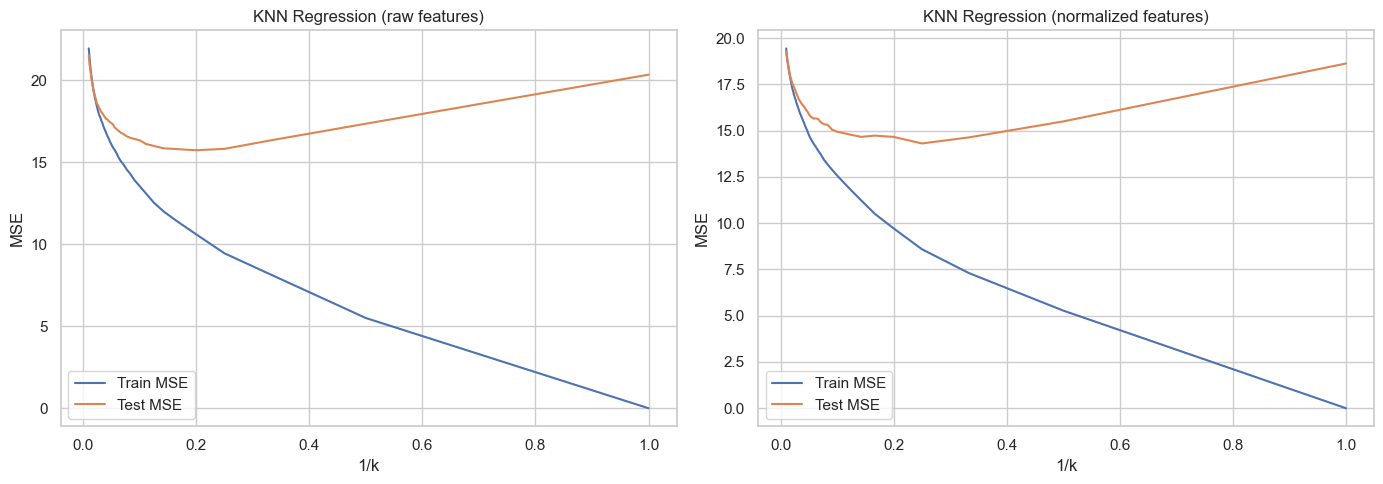

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, feature_type in zip(axes, ["raw", "normalized"]):
    subset = knn_results[knn_results["features"] == feature_type]
    ax.plot(subset["1/k"], subset["train_MSE"], label="Train MSE")
    ax.plot(subset["1/k"], subset["test_MSE"], label="Test MSE")
    ax.set_xlabel("1/k")
    ax.set_ylabel("MSE")
    ax.set_title(f"KNN Regression ({feature_type} features)")
    ax.legend()

plt.tight_layout()
plt.show()

The best `k` is selected by the smallest test MSE. Normalization is important for KNN because the method uses distances; variables measured on larger numeric scales can dominate the distance calculation when raw features are used.

## 1(j). KNN vs Best Linear Regression Model

In [16]:
comparison = pd.concat([
    mse_table[["model", "train_MSE", "test_MSE"]],
    best_knn.assign(model=lambda d: "KNN " + d["features"] + ", k=" + d["k"].astype(str))[["model", "train_MSE", "test_MSE"]],
], ignore_index=True).sort_values("test_MSE")
comparison

,model,train_MSE,test_MSE
2,"KNN normalized, k=4",8.591433,14.305669
3,"KNN raw, k=5",10.600769,15.726820
1,Selected: interactions + quadratics,17.890843,18.660040
0,Linear: all predictors,20.580840,21.239857


The selected regression model with interactions and quadratic terms is the best linear-model candidate from part 1(h). KNN may obtain a competitive test error, especially after normalization, but it is less interpretable than the regression model. The regression model also directly identifies significant main, nonlinear, and interaction effects; KNN is mainly useful here as a flexible predictive benchmark.

## 2. ISLR 2.4.1

For each situation, decide whether a flexible statistical learning method is expected to perform better or worse than an inflexible method.

**(a)** Better. With a very large sample size and a small number of predictors, a flexible method can learn the true relationship well without too much variance.

**(b)** Worse. When the number of predictors is large and the number of observations is small, a flexible method is likely to overfit.

**(c)** Better. If the true relationship is highly nonlinear, a flexible method is more likely to capture that structure.

**(d)** Worse. If the variance of the error terms is very high, a flexible method may fit noise and have poor test performance.

## 3. ISLR 2.4.7

The training observations are:

| Obs | X1 | X2 | X3 | Y |
|---:|---:|---:|---:|:--|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | -1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

The test point is \((0, 0, 0)\). The Euclidean distances are computed below.

In [17]:
islr = pd.DataFrame({
    "obs": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
})
test_point = np.array([0, 0, 0])
islr["distance"] = np.sqrt(((islr[["X1", "X2", "X3"]].values - test_point) ** 2).sum(axis=1))
islr.sort_values("distance")

,obs,X1,X2,X3,Y,distance
4,5,-1,0,1,Green,1.414214
5,6,1,1,1,Red,1.732051
1,2,2,0,0,Red,2.000000
3,4,0,1,2,Green,2.236068
0,1,0,3,0,Red,3.000000
2,3,0,1,3,Red,3.162278


**(a)** The Euclidean distances are shown in the table above.

**(b)** For \(K=1\), the nearest observation is observation 5, whose class is Green. The prediction is Green.

**(c)** For \(K=3\), the three nearest observations are 5, 6, and 2. Their classes are Green, Red, and Red, so the prediction is Red.

**(d)** If the Bayes decision boundary is highly nonlinear, the best value of \(K\) is expected to be small. A small \(K\) gives a more flexible classifier, while a large \(K\) produces a smoother and less flexible decision boundary.